# K Nearest Neighbors (KNN) and the curse of dimensionality.
In this test we will implement and explore a one-shot method for learned classification.

## Section 1 : Dataset (10 points)
We will first set up a couple datasets to use as well as create visualizations for them.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [2]:
class_one = {'mean':(2,0.5), 'std':(2,1), 'n_points':100}
class_two = {'mean':(0.5,1), 'std':(0.5,0.3), 'n_points':100}
distributions = [class_one, class_two]

def create_classification_data(distributions):
    '''
    Samples from the given gaussian distributions (each with mean, std, and number of points)
    returns a single dataset of all points with class labels corresponding to the index of the distribution in the distributions list

    You may assume that each distribution has the same dimenstions.
    '''
    dataset = []
    for i, dist in enumerate(distributions):
      mean     = dist['mean']
      std      = dist['std']
      n_points = dist['n_points']
      points = np.random.normal(loc=mean, scale=std, size=(n_points, len(mean)))
      labels = np.full(n_points, i)
      dataset.append((points, labels))
    return dataset

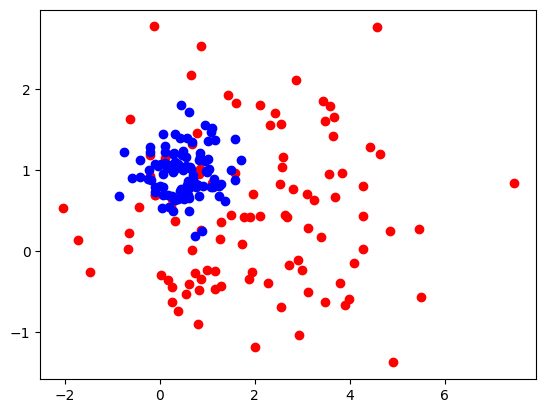

In [3]:
# TODO: Plot the points given the example distributions, each class should be its own color.
data = create_classification_data(distributions)
fig, ax = plt.subplots()
ax.scatter(data[0][0][:, 0], data[0][0][:, 1], color = 'red')
ax.scatter(data[1][0][:, 0], data[1][0][:, 1], color = 'blue')

plt.show()

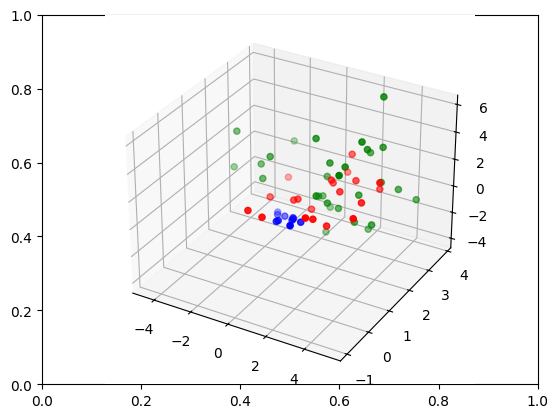

In [4]:
# TODO : Plot the points for data with these 3d distributions
class_one = {'mean':(2,0.5,3), 'std':(2,1,1), 'n_points':20}
class_two = {'mean':(0.5,1,0), 'std':(0.5,0.3,0), 'n_points':10}
class_three = {'mean':(1,3,1), 'std':(2,0.5,2), 'n_points':30}
distributions = [class_one, class_two, class_three]

data = create_classification_data(distributions)
fig, ax1 = plt.subplots()
ax = fig.add_subplot(projection='3d')

ax.scatter(data[0][0][:, 0], data[0][0][:, 1], data[0][0][:, 2], color='red')
ax.scatter(data[1][0][:, 0], data[1][0][:, 1], data[1][0][:, 2], color='blue')
ax.scatter(data[2][0][:, 0], data[2][0][:, 1], data[2][0][:, 2], color='green')

## Section 2: K Nearest Neighbors (20 points)
We will now implement a k-nearest neighbors classifier and observe its behavior

In [5]:
# 10 points -- implementation

def K_nearest_neighbor(k, point, data):
    '''
    Given a point (in cartesean space) determine the k closest (euclidean distance) datapoints.
    Return an integer (0, ..., C) corresponding to the most common class out of those k points where C is the final class (number of classes -1)

    Hint: Later sections may require you to run this on many datapoints, it may be beneficial to optimize the runtime of your algorithm
    '''
    X_train = np.array(data[:, :-1])
    y_train = np.array(data[:, -1], dtype=int)
    point = np.array(point)

    k = min(k, len(X_train))
    if k < 1:
        raise ValueError("k must be at least 1")

    sqdist = np.sum((X_train - point) ** 2, axis=1)
    k_indices = np.argpartition(sqdist, k - 1)[:k]
    k_nearest_labels = y_train[k_indices]
    most_common_class = np.argmax(np.bincount(k_nearest_labels))
    return int(most_common_class)

In [6]:
# 5 points -- testing

# TODO first measure the accuracy of your K nearest Neighbors implementation (5)
def measure_accuracy(k, train_data, test_data):
    '''
    Train_data and Test_data will both be tuples of coordinates and a class label (integer 0,...,C)

    Using your implementation of KNN and the training data predict a label for each test data point.
    return the accuracy of these labels as a percentage.
    '''

    train_points, train_labels = train_data[0]
    test_points,  test_labels  = test_data[0]
    train_combined = np.column_stack([train_points, train_labels])

    correct = 0
    total = len(test_points)

    for i in range(total):
        point = test_points[i]
        predicted = K_nearest_neighbor(k, point, train_combined)
        if predicted == test_labels[i]:
            correct += 1

    return (correct / total) * 100.0

train_data = create_classification_data(distributions)

test_dist = [{a: (dist[a] if a != 'n_points' else 10) for a in dist} for dist in distributions] # dictionary + list comprehension to change n_points to 10 for all dists
test_data = create_classification_data(test_dist)

print("accuracy at k = 4:", measure_accuracy(4,train_data,test_data))

accuracy at k = 4: 100.0


Best k: 1
Best accuracy: 100.0


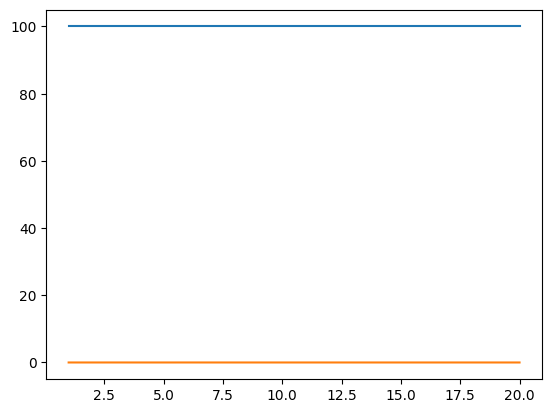

In [7]:
# 5 points -- Plotting

# TODO Plot k values versus accuracy, find the k value which has maximum accuracy.
# Also plot the runtime versus k value using the time library

import time

train_data = create_classification_data(distributions)
test_dist = [{a: (dist[a] if a != 'n_points' else 10) for a in dist} for dist in distributions] # dictionary + list comprehension to change n_points to 10 for all dists
test_data = create_classification_data(test_dist)

accuracies = []
runtimes = []
k_values = range(1, len(train_data[0][0]) + 1)

for k in k_values:
    start = time.time()
    acc = measure_accuracy(k, train_data, test_data)
    end = time.time()

    accuracies.append(acc)
    runtimes.append(end - start)

best_idx = np.argmax(accuracies)
best_k = list(k_values)[best_idx]
best_acc = accuracies[best_idx]

print("Best k:", best_k)
print("Best accuracy:", best_acc)

fig, ax = plt.subplots()
ax.plot(list(k_values), accuracies)
ax.plot(list(k_values), runtimes)

## Section 2.5 (Bonus) : Advanced Plotting (10 points)
Here is a chance to show off your plotting and DP skills. Don't attempt this unless you are sure of both of those.

In [8]:
# TODO Create a plot of the decision boundaries of your KNN Clustering algorithm

def plot_decision_boundary(k, train_data):
    '''
    This plot should have the training data plotted along with shaded regions for each of the areas in which your KNN classifies differently
    Regions' colors should correspond to the classes they predict.
    '''
    pass

# TODO Plot this for k = 1, k = 5 and your optimal k.

## Section 3 : High Dimensionality (20 points)
We will now explore how our method performs on high-dimensional data with noise

In [9]:
# 5 points -- High Dimenstion Data Test

# TODO modify your training and testing data to have 'additional_dims' additional dimensions all with mean 0 and std 0.2
def create_noisy_high_dim_data(distbutions, additional_dims, mean=0, std=0.2):
    '''
    ex. for additional dims = 2:
    {'mean':(2,0.5,3), 'std':(2,1,1), 'n_points':20} -> {'mean':(2,0.5,3,0,0), 'std':(2,1,1,0.2,0.2), 'n_points':20}

    then sample using your previous method
    '''

    class_one = {'mean':(2,0.5,3), 'std':(2,1,1), 'n_points':20}

    return


In [10]:
# 5 points -- plots (and runtime check)

# TODO using your optimal k value from above, create plots showing the accuracy and runtime of your KNN given different values of 'additonal dims' up to 50

### Question 3.1 (5 points)
Explain why the above behavior is happening, should we expect the same on real-world data?
</br></br>
**Answer**:

### Question 3.2 (5 points)
Provide a method to mitigate this issue, be detailed in explaining the method and why it will help fix this problem.
</br></br>
**Answer**:

## Section 3.5 (bonus) : 10 points
Here you can implement your suggestion from 3.2, you will score points based off of the effect it has along with the generality of the solution.

In [11]:
# TODO implement your fix here.

## Section 4: Adverserial Data (20 points)
Now we will look at an adverserial case and see if we have any way to still use KNN.

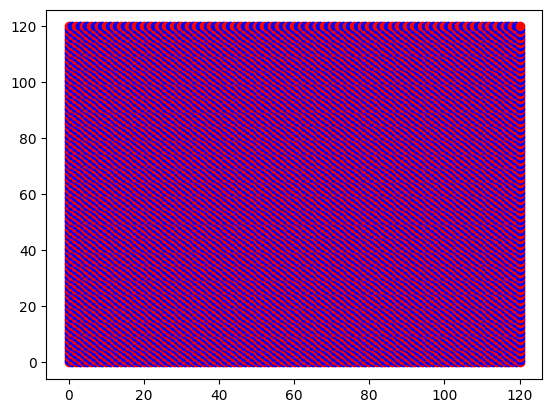

In [12]:
# 5 points -- Adverserial dataset

def create_adverserial_data(max_n):
    '''
    This dataset will contain all points [0,max_n]^2 -- i.e. (0,0), (0,1), ... (0, max_n), ..., (max_n, max_n)
    each point will be either class 0 or 1 which will be equal to its coordinates mod 2 (even or odd)

    i.e.  (0,0) -> 0, (1,2) -> 1, ... (a, b) -> a+b % 2
    '''
    data = []
    for i in range((max_n+1)**2):
      for j in range((max_n+1)**2):
        data.append((i, j))
    return data

adverserial_data = create_adverserial_data(10) # 121 points

# TODO plot this data
fig, ax = plt.subplots()

for i in range(len(adverserial_data)):
  if (adverserial_data[i][0] + adverserial_data[i][1]) % 2 == 1:
    ax.scatter(adverserial_data[i][0], adverserial_data[i][1], color = 'blue')
  if (adverserial_data[i][0] + adverserial_data[i][1]) % 2 == 0:
    ax.scatter(adverserial_data[i][0], adverserial_data[i][1], color = 'red')

plt.show()

In [13]:
# 5 points -- Testing on Adverserial Data

# TODO create a plot of k versus accuracy (same as Section 2) for this new data.

In [14]:
# 5 points -- Trigonometric Basis Expansion

# TODO Write a method that will convert a dataset via trigonometric basis expansion.
def trig_basis_expansion(data, scale):
    '''
    Basis expand the input data, such that:
    (x,y) -> (sin(nx), cos(nx), sin(ny), cos(ny))

    where n = scale
    '''
    for i in range(len(data)):
      val = data[i]
      for j in range(len(val)):
        val.append((np.sin(val[j]), np.cos(val[j])))
        val.pop(val[j]) # or whatever the orig val is
    return

# TODO Seperate out 1/5 of the data points to create a train and test set, then (after basis expanding):
# Plot your KNNs accuracy versus a few scale value in the range 1 - 5.

### Question 4.1 (5 points):
What value(s) of scale allow for 100% accuracy on this particular dataset, why? Justify your answer.
</br></br>
**Answer:**

## Section 5: Open Ended (30 points)
Now we will try our method on a real Dataset to see how it performs

In [19]:
# You may use any libraries you would like for this section, though you MUST use your above implementation of KNN as the basis of your solution.
from torch.utils.data import DataLoader
# We will be using MNIST as the dataset (to make it tractable computationally)
def load_mnist(batch_size=32, train=True):

    to_tensor_transform = torchvision.transforms.ToTensor() # You may remove this if you would like to use non-tensors
    dataset = torchvision.datasets.MNIST('../dataset/', train=train, download=True, transform=to_tensor_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) # You may also find it easier to deal with just the dataset and not the dataloader

    return dataset, dataloader

train_dataset, train_dataloader = load_mnist()
test_dataset, test_dataloader = load_mnist(train=False)

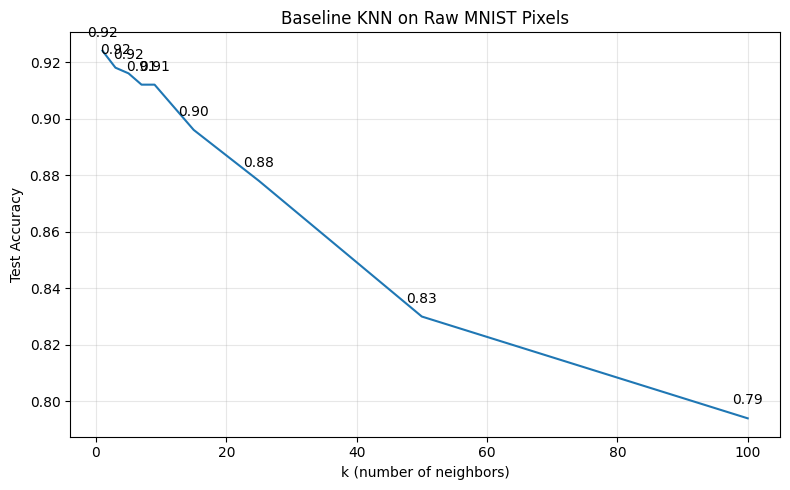

In [26]:
# 5 points -- Test without modification

# TODO test your model without modification (you may need to just use a subset of the dataset) and
# plot k versus accuray.

def dataset_to_arrays(dataset, n_samples, seed=0):
    idx = np.random.RandomState(seed).permutation(len(dataset))[:n_samples]
    X = np.stack([dataset[i][0].numpy().flatten() for i in idx])
    y = np.array([dataset[i][1] for i in idx])
    return X, y

X_train, y_train = dataset_to_arrays(train_dataset, n_samples=2000, seed=0)
X_test,  y_test  = dataset_to_arrays(test_dataset,  n_samples=500,  seed=1)

k_values = [1, 3, 5, 7, 9, 15, 25, 50, 100]
accuracies = []
for k in k_values:
    preds = np.zeros(len(X_test), dtype=y_train.dtype)
    for i, x in enumerate(X_test):
        dists = np.linalg.norm(X_train - x, axis=1)
        nn_idx = np.argpartition(dists, k)[:k]
        nn_labels = y_train[nn_idx]
        vals, counts = np.unique(nn_labels, return_counts=True)
        preds[i] = vals[np.argmax(counts)]
    acc = np.mean(preds == y_test)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("Baseline KNN on Raw MNIST Pixels")
plt.grid(True, alpha=0.3)
for k, a in zip(k_values, accuracies):
    plt.annotate(f"{a:.2f}", (k, a), textcoords="offset points", xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()

[Improved] k =   1  |  acc = 0.9240
[Improved] k =   3  |  acc = 0.9280
[Improved] k =   5  |  acc = 0.9220
[Improved] k =   7  |  acc = 0.9200
[Improved] k =   9  |  acc = 0.9180
[Improved] k =  15  |  acc = 0.9060
[Improved] k =  25  |  acc = 0.8860
[Improved] k = 100  |  acc = 0.8000
[Improved] k = 200  |  acc = 0.7440
[Improved] k = 1000  |  acc = 0.5160


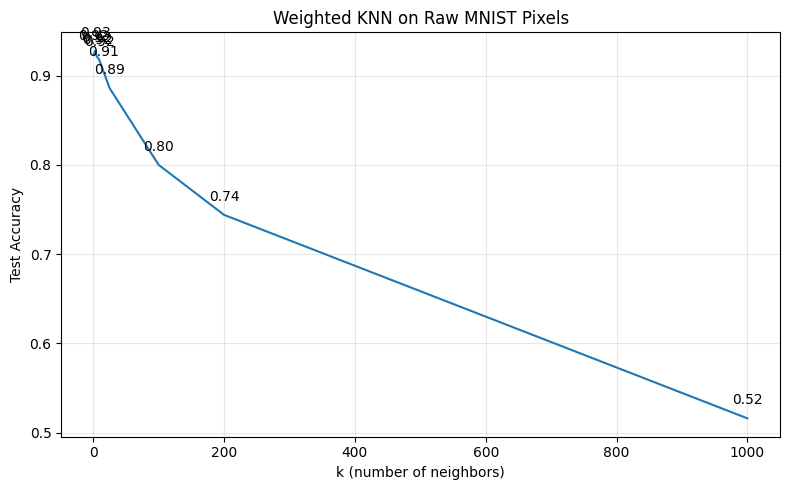

In [30]:
# 25 points -- Any method you'd like

# TODO Using any modifications of your choosing, implement a KNN which can accurately predict MNIST.
# You must show plots which explain your models behavior and you should explain your methodology in a markdown section

#weighted neighbors

k_values = [1, 3, 5, 7, 9, 15, 25, 100, 200, 1000]
accs = []
for k in k_values:
    preds = np.zeros(len(X_test), dtype=y_train.dtype)
    for i, x in enumerate(X_test):
        dists = np.linalg.norm(X_train - x, axis=1)
        nn_idx = np.argpartition(dists, k)[:k]
        nn_labels = y_train[nn_idx]
        nn_dists  = dists[nn_idx]
        weights = 1.0 / (nn_dists + 1e-8)
        vote_counts = {}
        for lbl, w in zip(nn_labels, weights):
            vote_counts[lbl] = vote_counts.get(lbl, 0.0) + w
        preds[i] = max(vote_counts, key=vote_counts.get)
    acc = np.mean(preds == y_test)
    accs.append(acc)
    print(f"[Improved] k = {k:3d}  |  acc = {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accs)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("Weighted KNN on Raw MNIST Pixels")
plt.grid(True, alpha=0.3)
for k, a in zip(k_values, accs):
    plt.annotate(f"{a:.2f}", (k, a), textcoords="offset points", xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()